# Informe Tecnico
Analisis de transacciones frudolentas

## 0. Carga de librerias

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display, Markdown

# Estilo visual
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 1. Carga de dataset

Debido a que el dataset original supera los 6 millones de registros, trabajar con él completo en análisis exploratorio sería innecesariamente costoso en tiempo y memoria.\nSe extrae una muestra aleatoria de 100,000 filas con random_state=42 para garantizar reproducibilidad.

Una muestra de este tamaño es estadísticamente representativa: por la Ley de los Grandes Números, las distribuciones, proporciones y correlaciones observadas en la muestra convergen a las del universo.

In [36]:
df = pd.read_csv('PaySim_Reducido.csv')
nRow, nCol = df.shape
print(f"Dataset cargado: {nRow:,} filas × {nCol} columnas.")

df.head()

Dataset cargado: 100,000 filas × 11 columnas.


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,278,CASH_IN,330218.42,C632336343,20866.00,351084.42,C834976624,452419.57,122201.15,0,0
1,15,PAYMENT,11647.08,C1264712553,30370.00,18722.92,M215391829,0.00,0.00,0,0
2,10,CASH_IN,152264.21,C1746846248,106589.00,258853.21,C1607284477,201303.01,49038.80,0,0
3,403,TRANSFER,1551760.63,C333676753,0.00,0.00,C1564353608,3198359.45,4750120.08,0,0
4,206,CASH_IN,78172.30,C813403091,2921331.58,2999503.88,C1091768874,415821.90,337649.60,0,0


## 2. Limpieza de datos

##### 2.1. Detección de valores imposibles

In [37]:
montos_neg = (df['amount'] < 0).sum()
bal_neg = (
    (df['oldbalanceOrg']  < 0) |
    (df['newbalanceOrig'] < 0) |
    (df['oldbalanceDest'] < 0) |
    (df['newbalanceDest'] < 0)
).sum()
bal_inc = df[
    (df['type'].isin(['TRANSFER', 'CASH_OUT'])) &
    (df['amount'] > df['oldbalanceOrg']) &
    (df['oldbalanceOrg'] > 0)
].shape[0]

print(f"Montos negativos          : {montos_neg}")
print(f"Balances negativos        : {bal_neg}")
print(f"Balances inconsistentes   : {bal_inc:,}  ({bal_inc/len(df)*100:.2f}% del total)")

Montos negativos          : 0
Balances negativos        : 0
Balances inconsistentes   : 18,721  (18.72% del total)


Decisión:  
- Montos y balances negativos: 0 registros → no se requiere acción.  
- Balances inconsistentes (monto > saldo antes): se CONSERVAN.

Justificación:  
en el contexto de fraude, que un retiro supere el saldo previo es una señal analítica valiosa; eliminar estos registros sesgaría el análisis hacia transacciones "normales".

In [38]:
df = df[
    (df['amount']         >= 0) &
    (df['oldbalanceOrg']  >= 0) &
    (df['newbalanceOrig'] >= 0) &
    (df['oldbalanceDest'] >= 0) &
    (df['newbalanceDest'] >= 0)
].reset_index(drop=True)
print(f"Tamaño final del dataset: {df.shape[0]:,} filas.")

Tamaño final del dataset: 100,000 filas.


## 3. Analisis de negocio

### 3.1. Segmentación de amount

Corte aplicado (mediana): $76,030.86

amount_categoria
Monto Bajo    50000
Monto Alto    50000
Name: count, dtype: int64


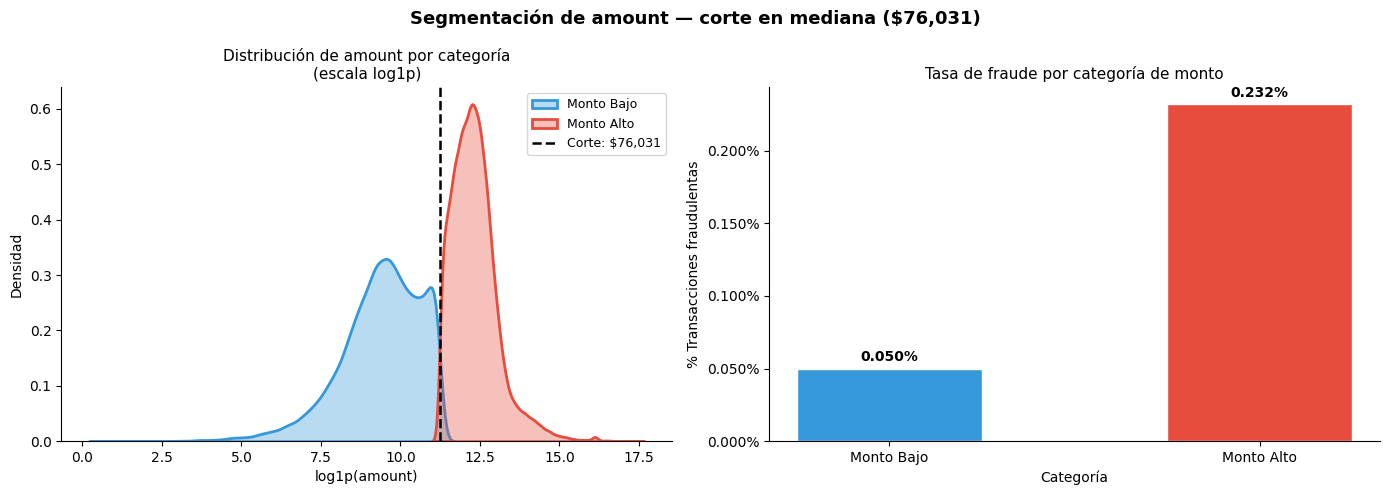

In [ ]:
df['amount_categoria'] = pd.cut(
    df['amount'],
    bins=[0, corte, float('inf')],
    labels=['Monto Bajo', 'Monto Alto'],
    include_lowest=True   
)

print(f"Corte aplicado (mediana): ${corte:,.2f}\n")
print(df['amount_categoria'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores = {'Monto Bajo': '#3498db', 'Monto Alto': '#e74c3c'}

amount_log = np.log1p(df['amount'])

for categoria, grupo in df.groupby('amount_categoria', observed=True):
    sns.kdeplot(
        np.log1p(grupo['amount']),
        ax=axes[0],
        label=categoria,
        color=colores[categoria],
        fill=True,
        alpha=0.35,
        linewidth=2
    )

axes[0].axvline(
    np.log1p(corte),
    color='black',
    linestyle='--',
    linewidth=1.8,
    label=f'Corte: ${corte:,.0f}'
)
axes[0].set_title('Distribución de amount por categoría\n(escala log1p)', fontsize=11)
axes[0].set_xlabel('log1p(amount)', fontsize=10)
axes[0].set_ylabel('Densidad', fontsize=10)
axes[0].legend(fontsize=9)

fraude_pct = (
    df.groupby('amount_categoria', observed=True)['isFraud']
    .mean()
    .mul(100)
    .reset_index()
)

bars = axes[1].bar(
    fraude_pct['amount_categoria'],
    fraude_pct['isFraud'],
    color=[colores[c] for c in fraude_pct['amount_categoria']],
    edgecolor='white',
    width=0.5
)

for bar, val in zip(bars, fraude_pct['isFraud']):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.005,
        f'{val:.3f}%',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

axes[1].set_title('Tasa de fraude por categoría de monto', fontsize=11)
axes[1].set_ylabel('% Transacciones fraudulentas', fontsize=10)
axes[1].yaxis.set_major_formatter(mtick.FormatStrFormatter('%.3f%%'))

plt.suptitle(
    f'Segmentación de amount — corte en mediana (${corte:,.0f})',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('amount_categorias.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.2. Amount por fraude

Nota: Se usa log1p(amount) en lugar de Z-Score para esta comparación.  

Razón: Al graficar dos grupos (fraude vs legítima) lo relevante es ver la DIFERENCIA de ubicación entre ambas distribuciones. Z-Score aplicado por grupo eliminaría esa diferencia, log1p comprime la escala sin perder la separación entre clases.

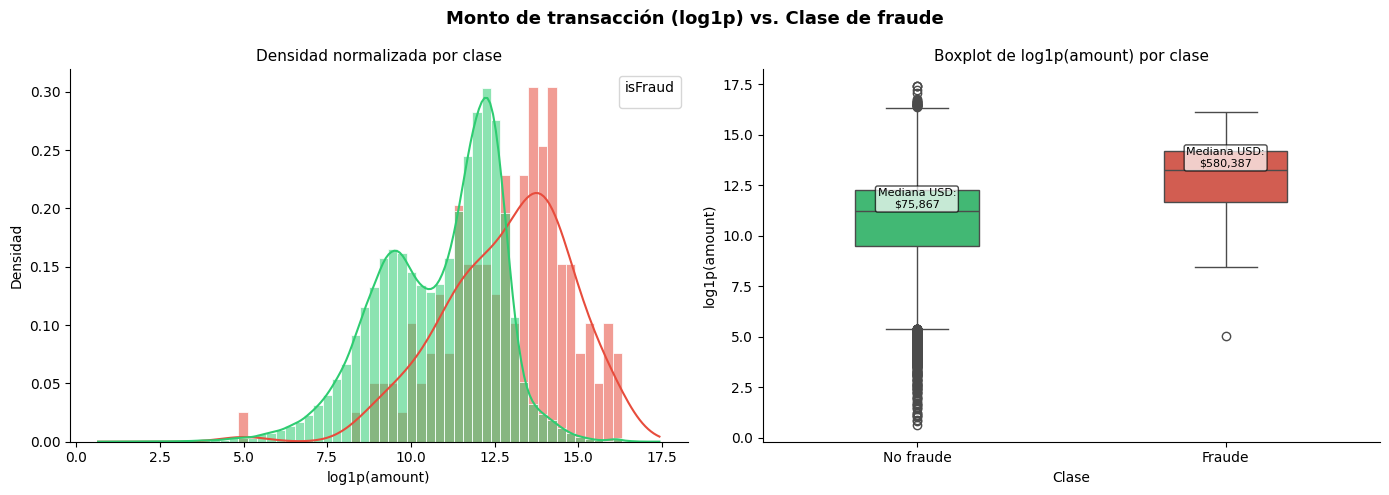

In [ ]:

sample = df
sample['amount_log'] = np.log1p(sample['amount'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=sample, x='amount_log', hue='isFraud',
    bins=60, kde=True, stat='density', common_norm=False,
    palette={0: '#2ecc71', 1: '#e74c3c'}, alpha=0.55,
    edgecolor='white', ax=axes[0]
)
axes[0].set_title('Densidad normalizada por clase', fontsize=11)
axes[0].set_xlabel('log1p(amount)', fontsize=10)
axes[0].set_ylabel('Densidad', fontsize=10)
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, ['0 — No fraude', '1 — Fraude'], title='isFraud')

sample['isFraud_lbl'] = sample['isFraud'].map({0: 'No fraude', 1: 'Fraude'})
orden_lbl = ['No fraude', 'Fraude']
sns.boxplot(
    data=sample, x='isFraud_lbl', y='amount_log',
    order=orden_lbl,
    hue='isFraud_lbl', hue_order=orden_lbl,
    palette={'No fraude': '#2ecc71', 'Fraude': '#e74c3c'},
    legend=False, ax=axes[1], width=0.4
)
axes[1].set_title('Boxplot de log1p(amount) por clase', fontsize=11)
axes[1].set_xlabel('Clase', fontsize=10)
axes[1].set_ylabel('log1p(amount)', fontsize=10)

# Anotar medianas reales (en USD) sobre el boxplot
for i, lbl in enumerate(orden_lbl):
    is_fraud_val = 1 if lbl == 'Fraude' else 0
    med_usd = df[df['isFraud'] == is_fraud_val]['amount'].median()
    med_log = np.log1p(med_usd)
    axes[1].text(i, med_log + 0.15,
                 f'Mediana USD:\n${med_usd:,.0f}',
                 ha='center', fontsize=8, color='black',
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

plt.suptitle('Monto de transacción (log1p) vs. Clase de fraude', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('4_5_amount_vs_fraud.png', dpi=120, bbox_inches='tight')
plt.show()

In [48]:
med_fraud    = df[df['isFraud']==1]['amount'].median()
med_nofraud  = df[df['isFraud']==0]['amount'].median()
mean_fraud   = df[df['isFraud']==1]['amount'].mean()
mean_nofraud = df[df['isFraud']==0]['amount'].mean()
print(f"  amount — Mediana  |  No fraude: ${med_nofraud:>12,.0f}  |  Fraude: ${med_fraud:>12,.0f}")
print(f"  amount — Media    |  No fraude: ${mean_nofraud:>12,.0f}  |  Fraude: ${mean_fraud:>12,.0f}")
print(f"  Ratio de medianas (fraude / no fraude): {med_fraud/med_nofraud:.1f}x\n")


  amount — Mediana  |  No fraude: $      75,867  |  Fraude: $     580,387
  amount — Media    |  No fraude: $     178,944  |  Fraude: $   1,340,223
  Ratio de medianas (fraude / no fraude): 7.7x



  - Las transacciones fraudulentas se concentran en montos significativamente
    más altos que las legítimas, como confirman mediana y media calculadas.
  - El histograma muestra que la distribución de fraude (rojo) tiene su pico
    desplazado hacia valores más altos de log1p(amount).
  - El boxplot hace explícita la diferencia de medianas en escala logarítmica;
    las medianas en USD se anotan directamente sobre la gráfica.
  - 'amount' es una feature discriminante de alto valor para detectar fraude.

### 3.3. Patrón de vaciado de cuenta

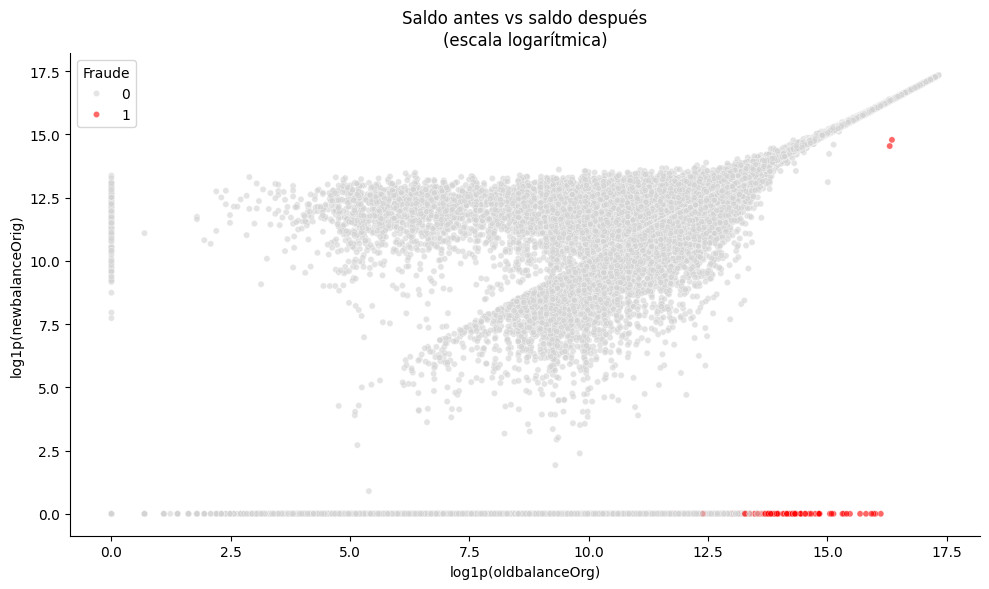

In [51]:
sample = df.copy()

sample['oldbalanceOrg_log'] = np.log1p(sample['oldbalanceOrg'])
sample['newbalanceOrig_log'] = np.log1p(sample['newbalanceOrig'])

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample,
    x='oldbalanceOrg_log',
    y='newbalanceOrig_log',
    hue='isFraud',
    palette={0:'lightgray',1:'red'},
    alpha=0.6,
    s=20
)

plt.title(
    'Saldo antes vs saldo después\n'
    '(escala logarítmica)'
)

plt.xlabel('log1p(oldbalanceOrg)')
plt.ylabel('log1p(newbalanceOrig)')

plt.legend(title='Fraude')
plt.tight_layout()
plt.show()


El gráfico revela una separación clara entre transacciones fraudulentas y legítimas. Los casos de fraude se concentran casi exclusivamente en tomas donde el saldo de la cuenta posterior a la trnasaccoin es cero, indicando un patrón consistente de vaciado completo de fondos. En contraste, las transacciones legítimas presentan una distribución mucho más dispersa y suelen conservar parte del saldo original. Este comportamiento sugiere que las variables oldbalanceOrg y especialmente newbalanceOrig poseen un alto poder discriminante para la detección de fraude